In [1]:
%pip install clickhouse-connect scikit-learn joblib

import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to ClickHouse via Docker Desktop bridge
client = clickhouse_connect.get_client(
    host='host.docker.internal', 
    port=8123, 
    username='admin', 
    password='secretpassword',
    database='telemetry'
)

# Fetch data. We want to see how many events each user triggered per day.
query = "SELECT event_date, event_type, total_events FROM daily_event_summary"
df = client.query_df(query)

print(f"Loaded {len(df)} records. Here's a preview:")
display(df.head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
Loaded 5 records. Here's a preview:


,event_date,event_type,total_events
0,2026-04-21,k8s_stateful_test,1
1,2026-04-21,grafana_spike_test,50
2,2026-04-22,prometheus_metrics_test,20
3,2026-04-22,distributed_trace_test,2
4,2026-04-23,stream_spam_test,40


In [2]:
from sklearn.ensemble import IsolationForest

# We will use 'total_events' as our feature to detect volume spikes (like DDoS or spam bots)
X = df[['total_events']]

# Initialize the model. 
# contamination=0.1 tells the model we estimate about 10% of our traffic is anomalous.
model = IsolationForest(contamination=0.1, random_state=42)

# Train the model AND predict in one step!
# It will return 1 for Normal, and -1 for Anomaly.
df['anomaly_score'] = model.fit_predict(X)

print("Anomaly Counts (1 = Normal, -1 = Anomaly):")
print(df['anomaly_score'].value_counts())

# Let's peek at the ones it flagged as anomalies!
display(df[df['anomaly_score'] == -1])

Anomaly Counts (1 = Normal, -1 = Anomaly):
anomaly_score
 1    4
-1    1
Name: count, dtype: int64


,event_date,event_type,total_events,anomaly_score
1,2026-04-21,grafana_spike_test,50,-1


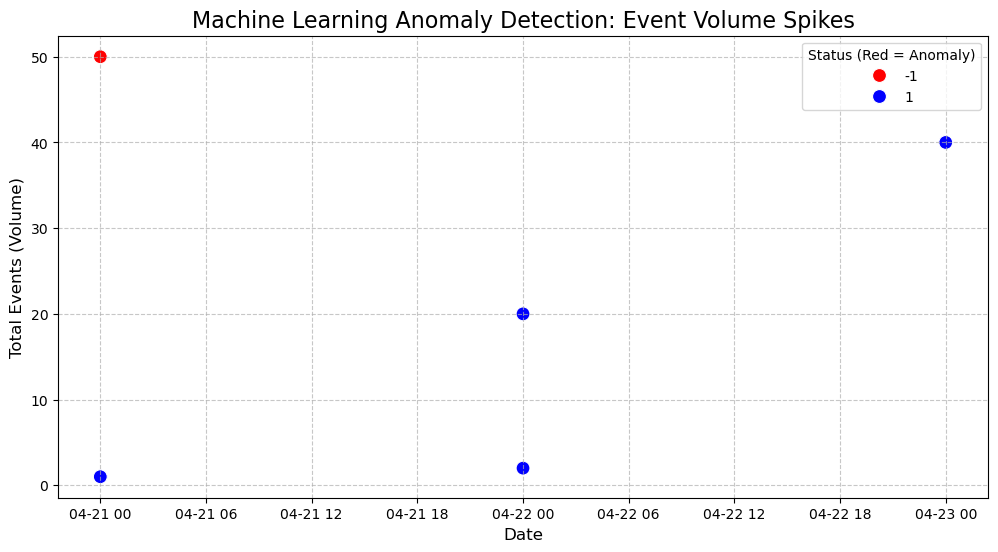

In [3]:
plt.figure(figsize=(12, 6))

# Plot the data, coloring it by the anomaly score
sns.scatterplot(
    data=df, 
    x='event_date', 
    y='total_events', 
    hue='anomaly_score', 
    palette={1: 'blue', -1: 'red'},
    s=100
)

plt.title("Machine Learning Anomaly Detection: Event Volume Spikes", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Events (Volume)", fontsize=12)
plt.legend(title="Status (Red = Anomaly)", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


In [4]:
import joblib

# Export the trained model to a file
joblib.dump(model, 'isolation_forest.joblib')

print("Model successfully exported as 'isolation_forest.joblib'!")


Model successfully exported as 'isolation_forest.joblib'!
